見つかったファイル: ['results_pz_0.0_Lx_18_Nd_1000_NT_9720.npz']
results_pz_0.0_Lx_18_Nd_1000_NT_9720.npz → Lx=18, Nd=1000, NT=9720, pz=0.0
results_pz_0.0_Lx_18_Nd_1000_NT_9720.npz: Lx= 18


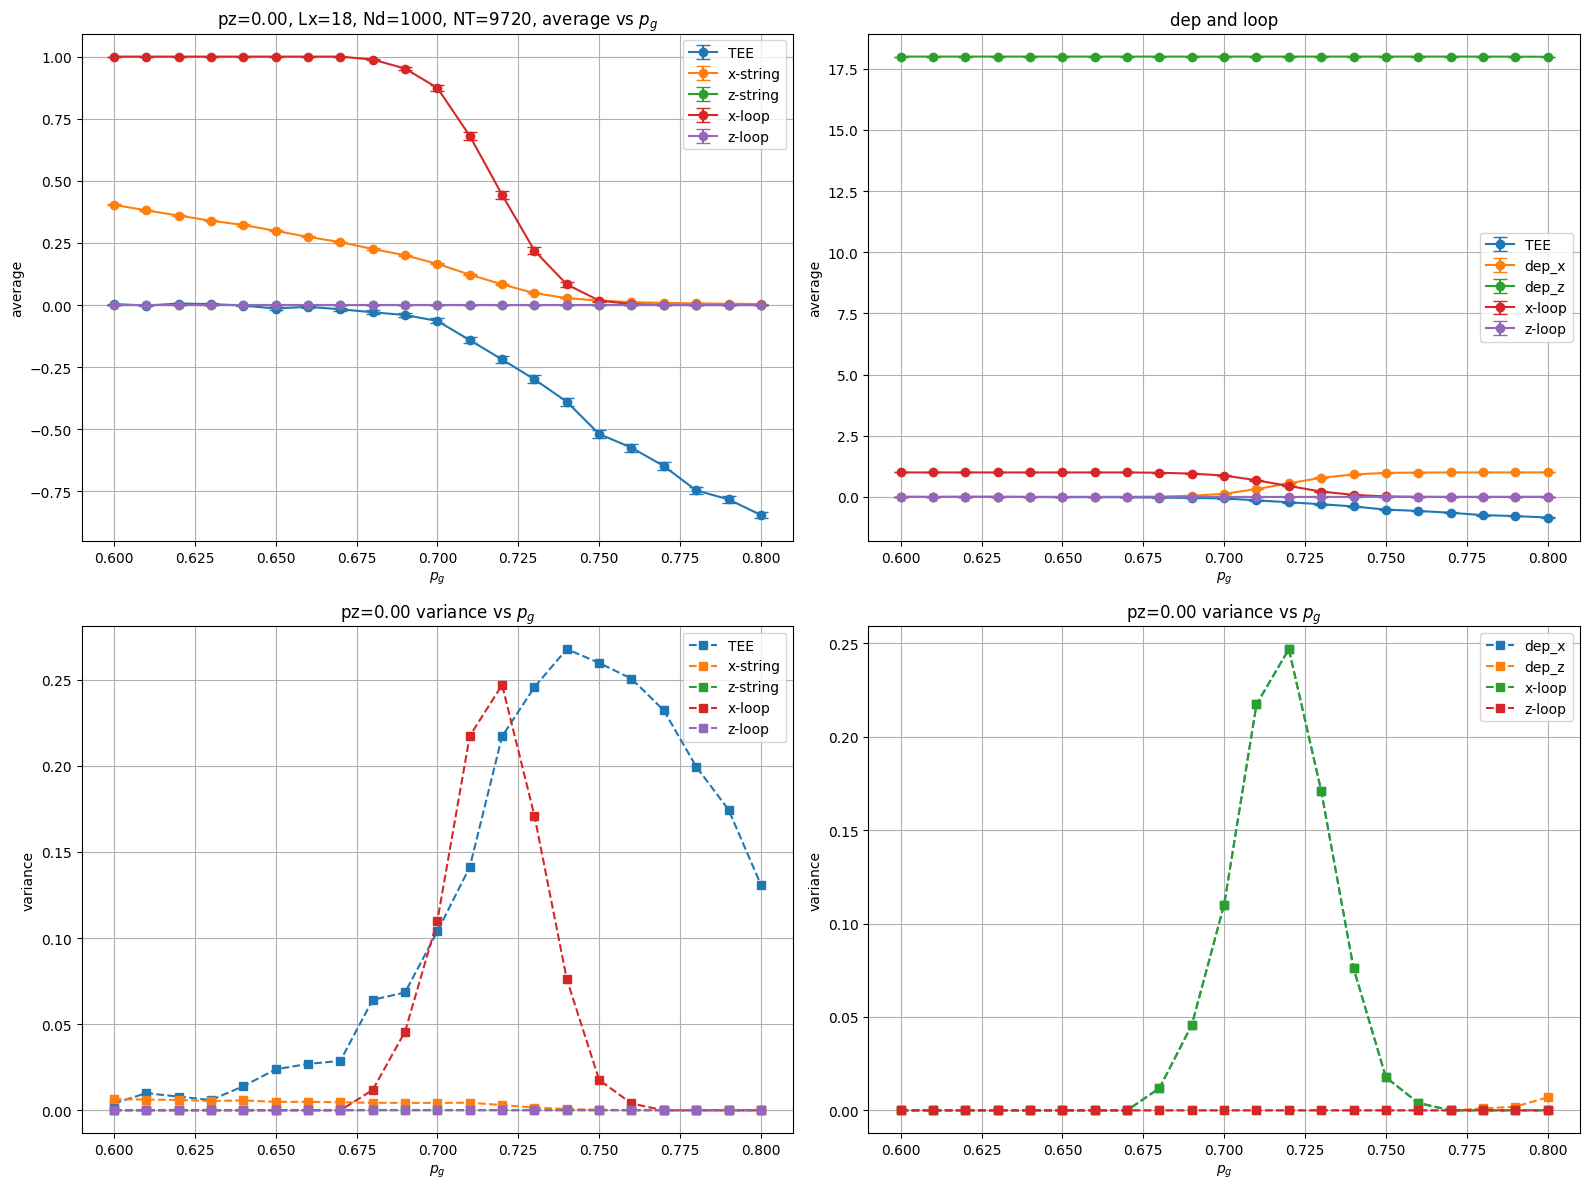

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

# カラーマップ設定
cmap = plt.colormaps['gnuplot']

# ファイル読み込み
files = glob.glob("results_pz_0.0_Lx_18_Nd_1000_NT_9720.npz")
print("見つかったファイル:", files)

for file in files:
    match = re.search(
        r"pz_([0-9.]+)_Lx_(\d+)_Nd_(\d+)_NT_(\d+)", file
    )
    if match:
        pz = float(match.group(1))
        Lx = int(match.group(2))
        Nd = int(match.group(3))
        NT = int(match.group(4))
        print(f"{file} → Lx={Lx}, Nd={Nd}, NT={NT}, pz={pz}")

# プロット用
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

for file in files:
    with np.load(file) as data:
        pg = data['pg']                      # ← 必ず最初に読み込む
        sort_idx = np.argsort(pg)           # ← 昇順インデックス
        pg = pg[sort_idx]                   # ← 並び替え
                
        TEE_ave = data['TEE_ave'][sort_idx]
        TEE_err = data['TEE_err'][sort_idx]
        TEE_var = data['TEE_var'][sort_idx]
        R2x_ave = data['R2x_ave'][sort_idx]
        R2x_err = data['R2x_err'][sort_idx]
        R2x_var = data['R2x_var'][sort_idx]
        R2z_ave = data['R2z_ave'][sort_idx]
        R2z_err = data['R2z_err'][sort_idx]
        R2z_var = data['R2z_var'][sort_idx]
        R2x_loop_ave = data['R2x_loop_ave'][sort_idx]
        R2x_loop_err = data['R2x_loop_err'][sort_idx]
        R2x_loop_var = data['R2x_loop_var'][sort_idx]
        R2z_loop_ave = data['R2z_loop_ave'][sort_idx]
        R2z_loop_err = data['R2z_loop_err'][sort_idx]
        R2z_loop_var = data['R2z_loop_var'][sort_idx]
        dep_x_ave = data['dep_x_ave'][sort_idx]
        dep_x_err = data['dep_x_err'][sort_idx]
        dep_x_var = data['dep_x_var'][sort_idx]
        dep_z_ave = data['dep_z_ave'][sort_idx]
        dep_z_err = data['dep_z_err'][sort_idx]
        dep_z_var = data['dep_z_var'][sort_idx]

    #label = f"px={px:.2f}"
    label =f"ee"
    # 左グラフ：TEEと相関の平均＋誤差
    ax[0,0].errorbar(pg, TEE_ave, yerr=TEE_err, fmt='o-', capsize=5, label="TEE")
    ax[0,0].errorbar(pg, R2x_ave, yerr=R2x_err, fmt='o-', capsize=5, label="x-string")
    ax[0,0].errorbar(pg, R2z_ave, yerr=R2z_err, fmt='o-', capsize=5, label="z-string")
    ax[0,0].errorbar(pg, R2x_loop_ave, yerr=R2x_loop_err, fmt='o-', capsize=5, label="x-loop")
    ax[0,0].errorbar(pg, R2z_loop_ave, yerr=R2z_loop_err, fmt='o-', capsize=5, label="z-loop")

    # 右グラフ：分散
    ax[0,1].errorbar(pg, TEE_ave, yerr=TEE_err, fmt='o-', capsize=5, label="TEE")
    ax[0,1].errorbar(pg, dep_x_ave, yerr=dep_x_err, fmt='o-', capsize=5, label="dep_x")
    ax[0,1].errorbar(pg, dep_z_ave, yerr=dep_z_err, fmt='o-', capsize=5, label="dep_z")
    ax[0,1].errorbar(pg, R2x_loop_ave, yerr=R2x_loop_err, fmt='o-', capsize=5, label="x-loop")
    ax[0,1].errorbar(pg, R2z_loop_ave, yerr=R2z_loop_err, fmt='o-', capsize=5, label="z-loop")

    ax[1,0].plot(pg, TEE_var, 's--', label="TEE")    
    ax[1,0].plot(pg, R2x_var, 's--', label="x-string")
    ax[1,0].plot(pg, R2z_var, 's--', label="z-string")
    ax[1,0].plot(pg, R2x_loop_var, 's--', label="x-loop")
    ax[1,0].plot(pg, R2z_loop_var, 's--', label="z-loop")
    
    ax[1,1].plot(pg, dep_x_var, 's--', label="dep_x")
    ax[1,1].plot(pg, dep_z_var, 's--', label="dep_z")
    ax[1,1].plot(pg, R2x_loop_var, 's--', label="x-loop")
    ax[1,1].plot(pg, R2z_loop_var, 's--', label="z-loop")
    print(f"{file}: Lx= {Lx}")

# 描画設定
ax[0,0].set_xlabel('$p_g$')
ax[0,0].set_ylabel('average')
ax[0,0].set_title(f"pz={pz:.2f}, Lx={Lx}, Nd={Nd}, NT={NT}, average vs $p_g$")
ax[0,0].grid(True)
ax[0,0].legend()

ax[0,1].set_xlabel('$p_g$')
ax[0,1].set_ylabel('average')
ax[0,1].set_title("dep and loop")
ax[0,1].grid(True)
ax[0,1].legend()

ax[1,0].set_xlabel('$p_g$')
ax[1,0].set_ylabel('variance')
ax[1,0].set_title(f"pz={pz:.2f} variance vs $p_g$")
ax[1,0].grid(True)
ax[1,0].legend()

ax[1,1].set_xlabel('$p_g$')
ax[1,1].set_ylabel('variance')
ax[1,1].set_title(f"pz={pz:.2f} variance vs $p_g$")
ax[1,1].grid(True)
ax[1,1].legend()

plt.tight_layout()
plt.savefig(f"pz_{pz:.2f}_Lx_{Lx}_Nd_{Nd}_NT_{NT}_results.png", dpi=300, bbox_inches='tight')
plt.show()


In [5]:
import numpy as np

data = np.load("results_pz_0.0_Lx_18_Nd_1000_NT_9720.npz")
print(data.files)  # 保存されているキーの一覧を表示
data.close()

['pg', 'TEE_ave', 'TEE_err', 'TEE_var', 'R2x_ave', 'R2x_err', 'R2x_var', 'R2z_ave', 'R2z_err', 'R2z_var', 'R2x_loop_ave', 'R2x_loop_err', 'R2x_loop_var', 'R2z_loop_ave', 'R2z_loop_err', 'R2z_loop_var', 'dep_x_ave', 'dep_x_err', 'dep_x_var', 'dep_z_ave', 'dep_z_err', 'dep_z_var']


In [6]:
import numpy as np

data = np.load("results_pz_0.0_Lx_18_Nd_1000_NT_9720.npz")
print(data['pg'])
print(data['R2x_ave'])
print(data['R2x_err'])
print(data['R2x_var'])
print(data['R2x_loop_ave'])
print(data['R2x_loop_err'])
print(data['R2x_loop_var'])
data.close()

[0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69 0.7  0.71 0.72 0.73
 0.74 0.75 0.76 0.77 0.78 0.79 0.8 ]
[0.40338235 0.38119608 0.36017647 0.33952288 0.32226471 0.29866993
 0.27454902 0.25339869 0.22566667 0.20051634 0.1658268  0.12243791
 0.08321242 0.04787908 0.02802288 0.01779739 0.01166667 0.00873856
 0.00669608 0.00525163 0.00431373]
[0.00254436 0.0025075  0.0024509  0.00233282 0.00239981 0.00222457
 0.00222729 0.00216876 0.00209441 0.00208985 0.00207337 0.00211844
 0.00174567 0.00128749 0.00083585 0.00055517 0.00033515 0.00024515
 0.0001969  0.00016126 0.00013901]
[6.46731786e-03 6.28126665e-03 6.00089927e-03 5.43661374e-03
 5.75331316e-03 4.94374547e-03 4.95584878e-03 4.69883805e-03
 4.38217228e-03 4.36308510e-03 4.29455499e-03 4.48328468e-03
 3.04432730e-03 1.65597846e-03 6.97940696e-04 3.07905976e-04
 1.12212183e-04 6.00380623e-05 3.87308193e-05 2.59788009e-05
 1.93045410e-05]
[1.    1.    1.    1.    1.    1.    1.    1.    0.988 0.952 0.874 0.681
 0.444 0.219 0.083 0.018 

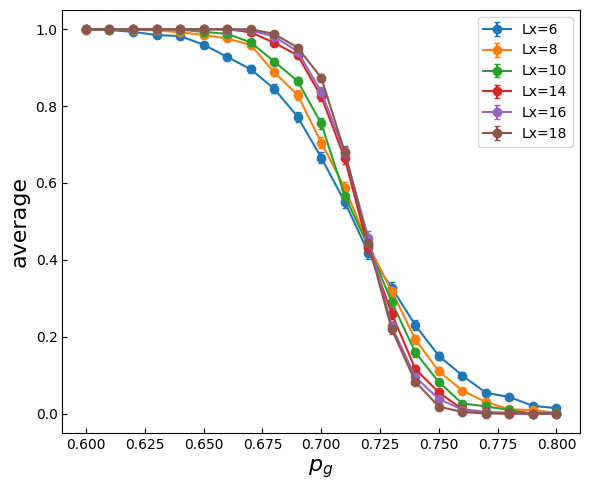

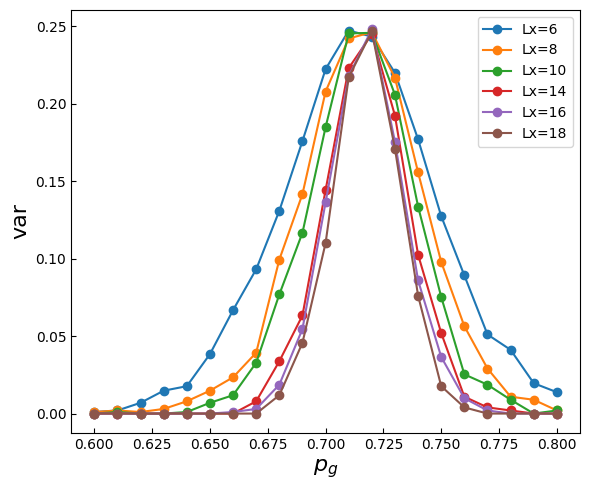

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

# 読み込むファイルパターン
files = glob.glob("results_pz_*_Lx_*_Nd_*_NT_*.npz")

data_by_L = {}

for fn in files:
    # ファイル名から Lx を抽出
    m = re.search(r"Lx_(\d+)", fn)
    if not m:
        continue
    Lx = int(m.group(1))

    # データを読み込む
    dat = np.load(fn)
    pg  = dat["pg"]
    ave = dat["R2x_loop_ave"]
    err = dat["R2x_loop_err"]
    var = dat["R2x_loop_var"]
    
    # サイズごとに格納
    data_by_L[Lx] = (pg, ave, err, var)


fig, ax = plt.subplots(figsize=(6,5))
for Lx, (pg, ave, err, var) in sorted(data_by_L.items()):
    ax.errorbar(pg, ave, yerr=err, fmt='o-', capsize=2, label=f"Lx={Lx}")

ax.set_xlabel(r"$p_g$", fontsize=16)
ax.set_ylabel("average", fontsize=16)
ax.grid(False)
ax.tick_params(direction="in", top=False, right=False)  # 左・下だけ内向き
ax.legend()
fig.tight_layout()
fig.savefig("px_0_xloop_ave.png", dpi=300, bbox_inches="tight")
plt.show()

# ===== プロット var =====
fig, ax = plt.subplots(figsize=(6,5))
for Lx, (pg, ave, err, var) in sorted(data_by_L.items()):
    ax.plot(pg, var, 'o-', label=f"Lx={Lx}")

ax.set_xlabel(r"$p_g$", fontsize=16)
ax.set_ylabel("var", fontsize=16)
ax.grid(False)
ax.tick_params(direction="in", top=False, right=False)
ax.legend()
fig.tight_layout()
fig.savefig("pz_0_xloop_var.png", dpi=300, bbox_inches="tight")
plt.show()